<a href="https://colab.research.google.com/github/iamamnabilal40/AI-Driven-Drug-Sales-Prediction-and-Stock-Level-Classification-for-Smart-Pharmacies/blob/main/AI_Pharmacy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Dataset load
df = pd.read_csv('https://raw.githubusercontent.com/iamamnabilal40/AI-Driven-Drug-Sales-Prediction-and-Stock-Level-Classification-for-Smart-Pharmacies/refs/heads/main/salesmonthly.csv')
df.head()
print(df.columns)

Index(['datum', 'M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03',
       'R06'],
      dtype='object')


In [3]:
# Check for missing values
print(df.isnull().sum())

df['datum'] = pd.to_datetime(df['datum'])
df['Year'] = df['datum'].dt.year
df['Month'] = df['datum'].dt.month

# Features (X) and Target (y)
X = df[['Year', 'Month']]
y = df['M01AB']

# Split data into Training and Test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

datum    0
M01AB    0
M01AE    0
N02BA    0
N02BE    0
N05B     0
N05C     0
R03      0
R06      0
dtype: int64


In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score
import numpy as np

# Choosing any medicine (e.g., M01AB) to use for testing
y_target = df['M01AB']

# --- 1. Simple/Multiple Linear Regression ---
# (Note: Year aur Month are two features so technically its Multiple Regression)
lr_model = LinearRegression()
lr_model.fit(X, y_target)
lr_pred = lr_model.predict(X)
lr_score = r2_score(y_target, lr_pred)

# --- 2. Polynomial Regression (Degree 2) ---
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)
poly_model = LinearRegression()
poly_model.fit(X_poly, y_target)
poly_pred = poly_model.predict(X_poly)
poly_score = r2_score(y_target, poly_pred)

# --- 3. Random Forest ---
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X, y_target)
rf_pred = rf_model.predict(X)
rf_score = r2_score(y_target, rf_pred)

# Results Print
print(f"1. Multiple Linear Regression R2: {lr_score:.4f}")
print(f"2. Polynomial Regression R2:      {poly_score:.4f}")
print(f"3. Random Forest Regressor R2:    {rf_score:.4f}")

1. Multiple Linear Regression R2: 0.0549
2. Polynomial Regression R2:      0.1740
3. Random Forest Regressor R2:    0.8820


In [5]:
# Model training
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)

# Prediction
y_pred_rf = rf_reg.predict(X_test)

print("Random Forest R2 Score:", r2_score(y_test, y_pred_rf))

Random Forest R2 Score: 0.6792781610992957


Mean Squared Error: 275.1994967807157
Root Mean Squared Error: 16.589137915537254


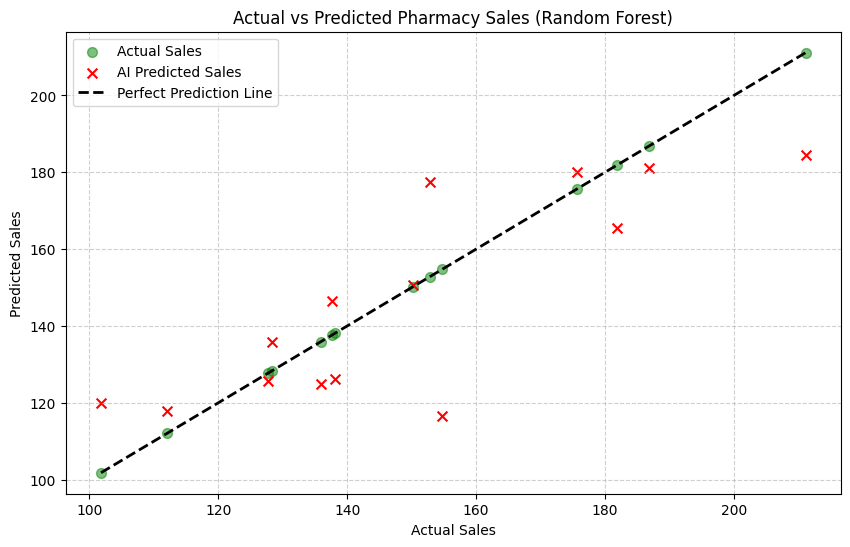

In [6]:
import matplotlib.pyplot as plt

mse = mean_squared_error(y_test, y_pred_rf)
rmse = np.sqrt(mse)

print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")

plt.figure(figsize=(10,6))

# 1. Actual Values
plt.scatter(y_test, y_test, color='green', label='Actual Sales', alpha=0.5, s=50)

# 2. Predicted Values
plt.scatter(y_test, y_pred_rf, color='red', label='AI Predicted Sales', marker='x', s=50)

# 3. Reference Line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Prediction Line')

plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Pharmacy Sales (Random Forest)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [7]:
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

# Prediction for months eg. (May 2026 input)
may_test = pd.DataFrame([[2026, 6]], columns=['Year', 'Month'])

print(f"{'Medicine':<10} | {'Status':<15} | {'Exact Units to Buy'}")
print("-" * 50)

# Define the list of medicine columns
medicines = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']

for med in medicines:
    # 1. Classification
    y_class = df[med].apply(lambda x: 0 if x < 50 else (1 if x < 150 else 2))
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X, y_class)
    pred_class = clf.predict(may_test)[0]
    status = "Low" if pred_class==0 else ("Medium" if pred_class==1 else "High")

    # 2. Regression
    reg = RandomForestRegressor(n_estimators=100, random_state=42)
    reg.fit(X, df[med])
    pred_units = reg.predict(may_test)[0]

    # Results print
    print(f"{med:<10} | {status:<15} | {pred_units:.2f} units")

Medicine   | Status          | Exact Units to Buy
--------------------------------------------------
M01AB      | High            | 156.95 units
M01AE      | Medium          | 100.77 units
N02BA      | Medium          | 102.74 units
N02BE      | High            | 626.23 units
N05B       | High            | 218.26 units
N05C       | Low             | 24.50 units
R03        | Medium          | 154.66 units
R06        | High            | 146.43 units
